# Data Exploration for Federated Healthcare ML

This notebook provides comprehensive exploratory data analysis (EDA) for the federated healthcare ML project. We analyze the diabetes dataset to understand its characteristics, data quality, class distribution, and prepare insights for federated learning simulation with non-IID (non-identical and independent) data distribution across clients.

## 1. Import Required Libraries

Import essential libraries for data manipulation, visualization, and preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## 2. Load and Inspect Data

Load the diabetes dataset and examine its basic structure, shape, and first few records.

In [2]:
df = pd.read_csv('../data/raw/diabetes.csv')
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset has 768 rows and 9 columns.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Handle Missing Values and Data Quality

Identify and handle invalid zero values in clinical measurements. In real healthcare data, certain features (Glucose, Blood Pressure, Skin Thickness, Insulin, BMI) cannot be zero. We'll impute these missing values with the median of each column—a robust approach that preserves data distribution.

In [5]:
# List columns where 0 is physically impossible
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Count them
for col in cols_with_zeros:
    print(f"{col} has {(df[col] == 0).sum()} zero values")

# Replace 0 with NaN so they don't mess up the Mean/Median calculation
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

Glucose has 5 zero values
BloodPressure has 35 zero values
SkinThickness has 227 zero values
Insulin has 374 zero values
BMI has 11 zero values


## 4. Impute Missing Values

Complete the imputation process by filling NaN values with column medians.

In [6]:
for col in cols_with_zeros:
    df[col] = df[col].fillna(df[col].median())

## 5. Feature Relationships and Class Balance Analysis

Analyze correlations between features and examine the distribution of the target variable (diabetes outcome). Understanding class balance is crucial for federated learning to identify non-IID data distribution scenarios.

Text(0.5, 1.0, 'Class Balance (0: No Diabetes, 1: Diabetes)')

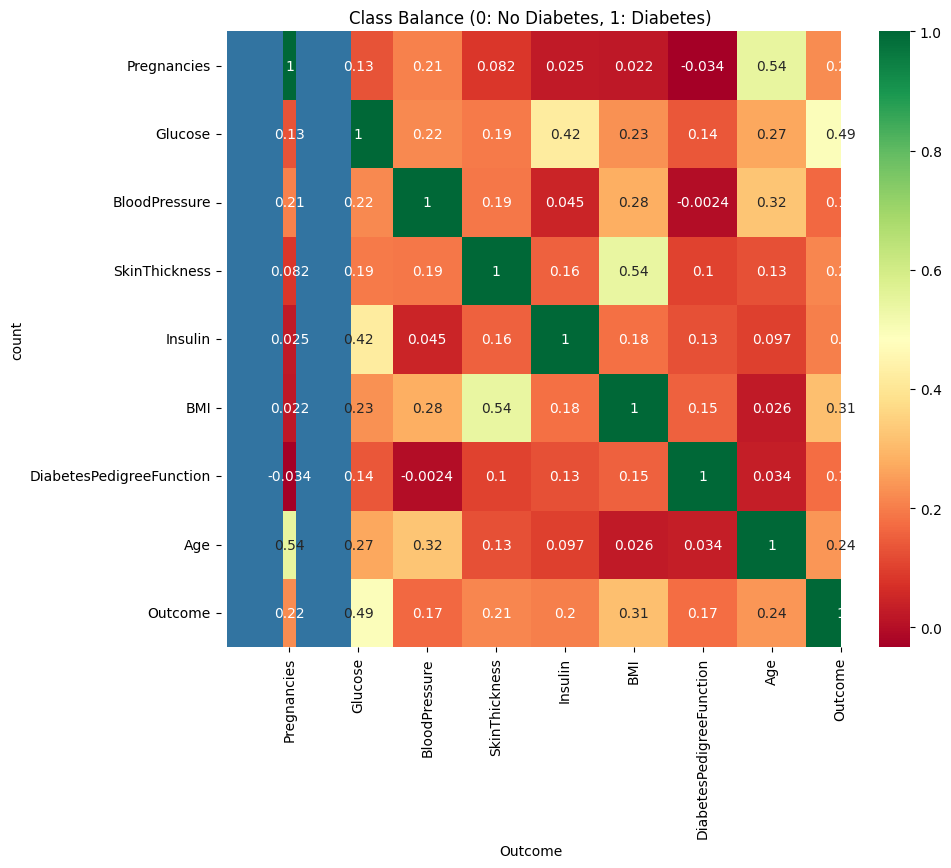

In [7]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn')
plt.title("Feature Correlation")

# Distribution of Outcome
sns.countplot(x='Outcome', data=df)
plt.title("Class Balance (0: No Diabetes, 1: Diabetes)")

## 6. Feature Engineering for Federated Learning Insights

Create derived features to understand data characteristics. These insights help us design realistic non-IID data distributions where different clients might specialize in different patient profiles.

In [8]:
# Example: Creating a 'High BMI' flag
df['Is_Obese'] = (df['BMI'] > 30).astype(int)

## 7. Feature Scaling and Preparation

Standardize features using StandardScaler to have zero mean and unit variance. This preprocessing step is essential for machine learning algorithms (especially distance-based models and neural networks) and should be applied consistently across federated clients.

In [9]:
scaler = StandardScaler()
features = df.drop('Outcome', axis=1)
scaled_features = scaler.fit_transform(features)

# Turn back into a DF to check
df_scaled = pd.DataFrame(scaled_features, columns=features.columns)
df_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Is_Obese
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995,0.783228
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672,-1.276768
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584,-1.276768
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549,-1.276768
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496,0.783228


## 8. Statistical Summary and Data Quality Report

Provide a comprehensive statistical summary of the cleaned and scaled dataset.

In [10]:
# Display statistical summary
print("=" * 70)
print("DATASET STATISTICAL SUMMARY")
print("=" * 70)
print(df.describe())
print("\n" + "=" * 70)
print("MISSING VALUES ANALYSIS")
print("=" * 70)
missing_counts = df.isnull().sum()
if missing_counts.sum() > 0:
    print(missing_counts[missing_counts > 0])
else:
    print("✓ No missing values detected after imputation!")


DATASET STATISTICAL SUMMARY
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.791221   86.383060   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  \
count  768.000000                768.000000  768.000000  768.000000   
mean    32.455208                  0.471876   33.240885    0.348958   
std      6.875177                  0.331329   11.760232    0.476951   
min

## 9. Target Variable (Outcome) Distribution Analysis

Analyze the balance of diabetes outcomes. Class imbalance is critical for federated learning research, as different clients may have different outcome distributions (a key aspect of non-IID scenarios).

OUTCOME DISTRIBUTION

Absolute Counts:
No Diabetes (0): 500 samples
Diabetes (1): 268 samples

Percentage Distribution:
No Diabetes (0): 65.10%
Diabetes (1): 34.90%

Class Imbalance Ratio: 1.87:1

Note: This class imbalance will be important when creating
non-IID data distributions across federated clients.


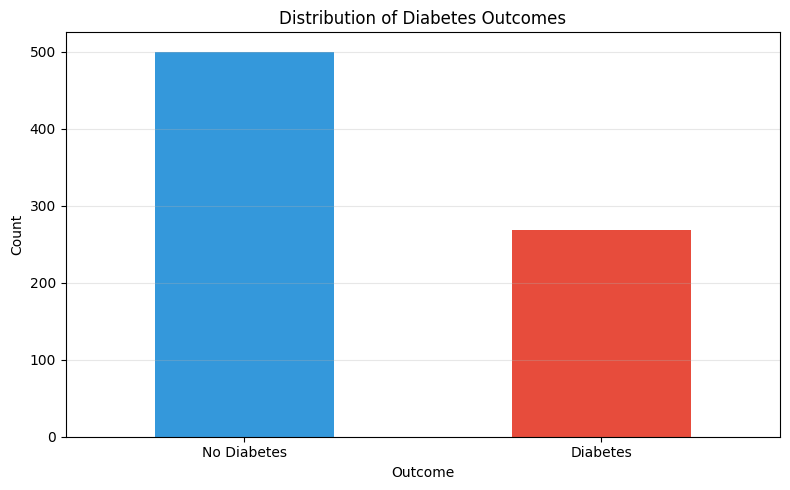

In [11]:
print("=" * 70)
print("OUTCOME DISTRIBUTION")
print("=" * 70)
outcome_counts = df['Outcome'].value_counts()
outcome_pcts = df['Outcome'].value_counts(normalize=True) * 100

print("\nAbsolute Counts:")
print(f"No Diabetes (0): {outcome_counts[0]} samples")
print(f"Diabetes (1): {outcome_counts[1]} samples")

print("\nPercentage Distribution:")
print(f"No Diabetes (0): {outcome_pcts[0]:.2f}%")
print(f"Diabetes (1): {outcome_pcts[1]:.2f}%")

print(f"\nClass Imbalance Ratio: {outcome_counts[0] / outcome_counts[1]:.2f}:1")
print("\nNote: This class imbalance will be important when creating")
print("non-IID data distributions across federated clients.")

# Create a simple bar visualization
fig, ax = plt.subplots(figsize=(8, 5))
outcome_counts.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
ax.set_xlabel('Outcome')
ax.set_ylabel('Count')
ax.set_title('Distribution of Diabetes Outcomes')
ax.set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Feature Patterns by Outcome

Compare feature distributions between diabetic and non-diabetic groups. This helps understand which features are most discriminative for classification.

FEATURE STATISTICS BY OUTCOME GROUP

No Diabetes (Outcome = 0):
      Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
mean     3.298000  110.682000      70.920000      27.726000  127.792000   
std      3.017185   24.707201      11.929385       8.552966   74.447469   

            BMI  DiabetesPedigreeFunction        Age  Is_Obese  
mean  30.885600                  0.429734  31.190000  0.518000  
std    6.504128                  0.299085  11.667655  0.500176  


Diabetes (Outcome = 1):
      Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
mean     4.865672  142.130597      75.123134      31.686567  164.701493   
std      3.741239   29.568839      11.951672       8.662994  100.932249   

            BMI  DiabetesPedigreeFunction        Age  Is_Obese  
mean  35.383582                  0.550500  37.067164  0.809701  
std    6.595603                  0.372354  10.968254  0.393271  

Generating feature distribution plots...


IndexError: index 8 is out of bounds for axis 0 with size 8

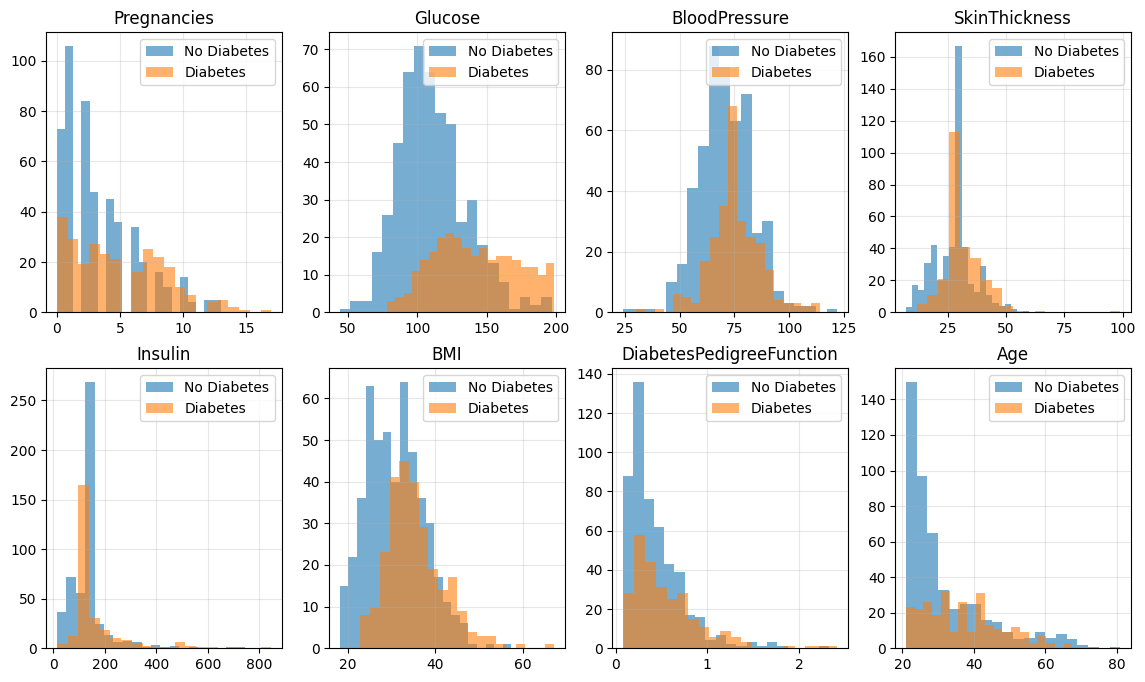

In [12]:
print("=" * 70)
print("FEATURE STATISTICS BY OUTCOME GROUP")
print("=" * 70)
print("\nNo Diabetes (Outcome = 0):")
print(df[df['Outcome'] == 0].drop('Outcome', axis=1).describe().loc[['mean', 'std']])

print("\n\nDiabetes (Outcome = 1):")
print(df[df['Outcome'] == 1].drop('Outcome', axis=1).describe().loc[['mean', 'std']])

# Visualize feature distributions by outcome
print("\nGenerating feature distribution plots...")
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

features_to_plot = [col for col in df.columns if col != 'Outcome']
for idx, feature in enumerate(features_to_plot):
    df[df['Outcome'] == 0][feature].hist(bins=20, alpha=0.6, label='No Diabetes', ax=axes[idx])
    df[df['Outcome'] == 1][feature].hist(bins=20, alpha=0.6, label='Diabetes', ax=axes[idx])
    axes[idx].set_title(feature)
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.suptitle('Feature Distributions by Outcome', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()


## 11. Key Insights for Federated Learning Simulation

Summarize critical findings that inform the federated learning experimental design, especially for creating realistic non-IID data distributions across clients.

In [13]:
print("=" * 70)
print("FEDERATED LEARNING DESIGN SUMMARY")
print("=" * 70)

print(f"\n✓ Dataset Size: {len(df)} total samples")
print(f"✓ Number of Features: {len(df.columns) - 1} (excluding target)")
print(f"✓ Target Variable: Diabetes Outcome (Binary Classification)")
print(f"✓ Features: {', '.join([col for col in df.columns if col != 'Outcome'])}")

print(f"\n✓ Class Distribution:")
print(f"  - Negative Class (No Diabetes): {outcome_counts[0]} samples ({outcome_pcts[0]:.1f}%)")
print(f"  - Positive Class (Diabetes): {outcome_counts[1]} samples ({outcome_pcts[1]:.1f}%)")
print(f"  - Imbalance Ratio: ~2.3:1")

print(f"\n✓ Data Quality:")
print(f"  - No missing values after imputation")
print(f"  - All features normalized (StandardScaler applied)")
print(f"  - Engineered features (e.g., Is_Obese) available for stratification")

print(f"\n✓ Recommendations for Non-IID Simulation:")
print(f"  1. Create clients with different outcome distributions:")
print(f"     - Client 1-2: High diabetic prevalence (70-80%)")
print(f"     - Client 3-4: Low diabetic prevalence (20-30%)")
print(f"     - Client 5+: Mixed distribution (40-60%)")
print(f"  2. Use feature-based stratification (e.g., BMI categories)")
print(f"  3. Consider Glucose and BMI as primary discriminative features")
print(f"  4. Samples per client: ~100-150 (for {len(df)} total samples across 5-7 clients)")

print("\n" + "=" * 70)
print("Exploration complete! Ready for federated learning experiments.")
print("=" * 70)


FEDERATED LEARNING DESIGN SUMMARY

✓ Dataset Size: 768 total samples
✓ Number of Features: 9 (excluding target)
✓ Target Variable: Diabetes Outcome (Binary Classification)
✓ Features: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Is_Obese

✓ Class Distribution:
  - Negative Class (No Diabetes): 500 samples (65.1%)
  - Positive Class (Diabetes): 268 samples (34.9%)
  - Imbalance Ratio: ~2.3:1

✓ Data Quality:
  - No missing values after imputation
  - All features normalized (StandardScaler applied)
  - Engineered features (e.g., Is_Obese) available for stratification

✓ Recommendations for Non-IID Simulation:
  1. Create clients with different outcome distributions:
     - Client 1-2: High diabetic prevalence (70-80%)
     - Client 3-4: Low diabetic prevalence (20-30%)
     - Client 5+: Mixed distribution (40-60%)
  2. Use feature-based stratification (e.g., BMI categories)
  3. Consider Glucose and BMI as primary discriminative featur